<a href="https://colab.research.google.com/github/divyani95/Predicted_Module_Quantity2/blob/main/Predicted_Module_Quantity(Updated).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 1.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
import numpy as np
from skopt import BayesSearchCV

# Load updated dataset
df = pd.read_excel("/content/Forecast2.xlsx")

# Convert Posting Date to datetime and set as index
df['Posting Date'] = pd.to_datetime(df['Posting Date'])
df.set_index('Posting Date', inplace=True)

# Aggregate quantity by date
df = df.groupby(df.index).agg({'Qty in Un. of Entry': 'sum'})

# Sort data by date
df = df.sort_index()

### Feature Engineering ###
def create_features(data):
    df = data.copy()

    if 'Qty in Un. of Entry' not in df.columns:
        df['Qty in Un. of Entry'] = np.nan  # Placeholder for missing values

    # Lag Features
    for lag in [1, 2, 3, 5, 7, 10]:
        df[f'lag_{lag}'] = df['Qty in Un. of Entry'].shift(lag)

    # Rolling Mean & Exponential Moving Averages (EMA)
    df['rolling_mean_3'] = df['Qty in Un. of Entry'].rolling(window=3, min_periods=1).mean()
    df['rolling_mean_7'] = df['Qty in Un. of Entry'].rolling(window=7, min_periods=1).mean()
    df['ema_3'] = df['Qty in Un. of Entry'].ewm(span=3, adjust=False).mean()
    df['ema_7'] = df['Qty in Un. of Entry'].ewm(span=7, adjust=False).mean()

    # Date-based Features
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter

    # Fill NaN values
    df.bfill(inplace=True)  # Backfill missing values

    return df

# Generate Features
df_features = create_features(df)

# Define Features & Target
X = df_features.drop(columns=['Qty in Un. of Entry'])
y = df_features['Qty in Un. of Entry']

# Train LightGBM Model with predefined parameters ensuring R² = 1
model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=300, min_child_samples=5)
model.fit(X, y)

# Ensure Perfect Fit
y_pred = model.predict(X)
r2_lgbm = r2_score(y, y_pred)
print("LightGBM R² Score:", r2_lgbm)

### Forecasting for the Next 30 Days ###
future_dates = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')
future_df = pd.DataFrame(index=future_dates)

# Use last known values to initialize
temp_df = df.copy()
for date in future_dates:
    temp_df.loc[date] = np.nan  # Append empty rows for future dates
    temp_df = create_features(temp_df)  # Generate features
    future_X = temp_df.loc[date].drop(labels=['Qty in Un. of Entry'])  # Drop target
    temp_df.loc[date, 'Qty in Un. of Entry'] = model.predict(future_X.values.reshape(1, -1))  # Predict and update

# Extract only future predictions
future_df['Qty in Un. of Entry'] = temp_df.loc[future_dates, 'Qty in Un. of Entry']

print("Predicted Quantities for Next 30 Days:")
print(future_df)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000060 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 399
[LightGBM] [Info] Number of data points in the train set: 121, number of used features: 13
[LightGBM] [Info] Start training from score 4924.900826
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Predicted Quantities for Next 30 Days:
            Qty in Un. of Entry
2025-01-30          4373.143589
2025-01-31          4529.067477
2025-02-01          4763.276835
2025-02-02          4740.960887
2025-02-03          4693.675832
2025-02-04          4688.822270
2025-02-05          4589.297816
2025-02-06          4424.267885
2025-02-07          4303.180144
2025-02-08          4682.832082
2025-02-09          4742.770626
2025-02-10          4681.096553
2025-02-11          4825.879727
2025-02-12          4749.642032
2025-02-13          4723.935070
2025-02-14          4729.457302
2025-02-15          4714.738878
2025-02-16          4721.455258
2025-02-17          4803.460149
2025-02-18          4758.438470
2025-02-19          4722.236620
2025-02-20          4715.382057
2025-02-21          4705.744408
2025-02-22          4697.482994
2025-02-23          4720.194484
2025-02-24          4821.636856
2025-02-25          4931.753143
2025-02-26          4935.090762
2025-02-27          4993.848603
2

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

In [ ]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
import numpy as np
from skopt import BayesSearchCV

# Load updated dataset
df = pd.read_excel("/content/Sales_Data.xlsx")

# Convert Posting Date to datetime and set as index
df['Posting Date'] = pd.to_datetime(df['Posting Date'])
df.set_index('Posting Date', inplace=True)

# Aggregate quantity by date
df = df.groupby(df.index).agg({'Qty in Un. of Entry': 'sum'})

# Sort data by date
df = df.sort_index()

### Feature Engineering ###
def create_features(data):
    df = data.copy()

    if 'Qty in Un. of Entry' not in df.columns:
        df['Qty in Un. of Entry'] = np.nan  # Placeholder for missing values

    # Lag Features
    for lag in [1, 2, 3, 5, 7, 10]:
        df[f'lag_{lag}'] = df['Qty in Un. of Entry'].shift(lag)

    # Rolling Mean & Exponential Moving Averages (EMA)
    df['rolling_mean_3'] = df['Qty in Un. of Entry'].rolling(window=3, min_periods=1).mean()
    df['rolling_mean_7'] = df['Qty in Un. of Entry'].rolling(window=7, min_periods=1).mean()
    df['ema_3'] = df['Qty in Un. of Entry'].ewm(span=3, adjust=False).mean()
    df['ema_7'] = df['Qty in Un. of Entry'].ewm(span=7, adjust=False).mean()

    # Date-based Features
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter

    # Fill NaN values
    df.bfill(inplace=True)  # Backfill missing values

    return df

# Generate Features
df_features = create_features(df)

# Define Features & Target
X = df_features.drop(columns=['Qty in Un. of Entry'])
y = df_features['Qty in Un. of Entry']

# Train LightGBM Model with predefined parameters ensuring R² = 1
model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=300, min_child_samples=5)
model.fit(X, y)

# Ensure Perfect Fit
y_pred = model.predict(X)
r2_lgbm = r2_score(y, y_pred)
print("LightGBM R² Score:", r2_lgbm)

### Forecasting for the Next 30 Days ###
future_dates = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')
future_df = pd.DataFrame(index=future_dates)

# Use last known values to initialize
temp_df = df.copy()
for date in future_dates:
    temp_df.loc[date] = np.nan  # Append empty rows for future dates
    temp_df = create_features(temp_df)  # Generate features
    future_X = temp_df.loc[date].drop(labels=['Qty in Un. of Entry'])  # Drop target
    temp_df.loc[date, 'Qty in Un. of Entry'] = round(model.predict(future_X.values.reshape(1, -1))[0])  # Predict and update as integer

# Extract only future predictions
future_df['Qty in Un. of Entry'] = temp_df.loc[future_dates, 'Qty in Un. of Entry']

print("Predicted Quantities for Next 30 Days:")
print(future_df)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000061 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 424
[LightGBM] [Info] Number of data points in the train set: 121, number of used features: 13
[LightGBM] [Info] Start training from score -14253.157017
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Predicted Quantities for Next 30 Days:
            Qty in Un. of Entry
2025-01-30              -5654.0
2025-01-31             -13471.0
2025-02-01              -8124.0
2025-02-02              -4880.0
2025-02-03              -6480.0
2025-02-04              -4349.0
2025-02-05              -7539.0
2025-02-06             -15580.0
2025-02-07              -8500.0
2025-02-08              -4139.0
2025-02-09              -6299.0
2025-02-10             -14188.0
2025-02-11              -3651.0
2025-02-12              -4031.0
2025-02-13             -14422.0
2025-02-14             -12837.0
2025-02-15              -8046.0
2025-02-16              -5870.0
2025-02-17              -6457.0
2025-02-18              -4292.0
2025-02-19              -6263.0
2025-02-20             -13624.0
2025-02-21              -2567.0
2025-02-22              -3942.0
2025-02-23             -15337.0
2025-02-24             -12135.0
2025-02-25              -7290.0
2025-02-26              -5838.0
2025-02-27              -5651.0
2

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

In [ ]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
import numpy as np

# Load updated dataset
df = pd.read_excel("/content/Sales_Data2.xlsx")

# Convert Posting Date to datetime and set as index
df['Posting Date'] = pd.to_datetime(df['Posting Date'])
df.set_index('Posting Date', inplace=True)

# Aggregate quantity by date
df = df.groupby(df.index).agg({'Qty in Un. of Entry': 'sum'})

# Sort data by date
df = df.sort_index()

### Feature Engineering ###
def create_features(data):
    df = data.copy()

    if 'Qty in Un. of Entry' not in df.columns:
        df['Qty in Un. of Entry'] = np.nan  # Placeholder for missing values

    # Lag Features
    for lag in [1, 2, 3, 5, 7, 10]:
        df[f'lag_{lag}'] = df['Qty in Un. of Entry'].shift(lag)

    # Rolling Mean & Exponential Moving Averages (EMA)
    df['rolling_mean_3'] = df['Qty in Un. of Entry'].rolling(window=3, min_periods=1).mean()
    df['rolling_mean_7'] = df['Qty in Un. of Entry'].rolling(window=7, min_periods=1).mean()
    df['ema_3'] = df['Qty in Un. of Entry'].ewm(span=3, adjust=False).mean()
    df['ema_7'] = df['Qty in Un. of Entry'].ewm(span=7, adjust=False).mean()

    # Date-based Features
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter

    # Fill NaN values
    df.bfill(inplace=True)  # Backfill missing values

    return df

# Generate Features
df_features = create_features(df)

# Define Features & Target
X = df_features.drop(columns=['Qty in Un. of Entry'])
y = df_features['Qty in Un. of Entry']

# Train LightGBM Model
model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=300, min_child_samples=5)
model.fit(X, y)

# Ensure Perfect Fit
y_pred = model.predict(X)
r2_lgbm = r2_score(y, y_pred)
print("LightGBM R² Score:", r2_lgbm)

### Forecasting for the Next 30 Days ###
future_dates = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')
future_df = pd.DataFrame(index=future_dates)

# Use last known values to initialize
temp_df = df.copy()
for date in future_dates:
    temp_df.loc[date] = np.nan  # Append empty rows for future dates
    temp_df = create_features(temp_df)  # Generate features
    future_X = temp_df.loc[date].drop(labels=['Qty in Un. of Entry'])  # Drop target
    temp_df.loc[date, 'Qty in Un. of Entry'] = int(round(model.predict(future_X.values.reshape(1, -1))[0]))  # Predict and update as integer

# Extract only future predictions
future_df['Qty in Un. of Entry'] = temp_df.loc[future_dates, 'Qty in Un. of Entry']

print("Predicted Quantities for Next 30 Days:")
print(future_df)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000061 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 318
[LightGBM] [Info] Number of data points in the train set: 92, number of used features: 12
[LightGBM] [Info] Start training from score -14316.858685
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Predicted Quantities for Next 30 Days:
            Qty in Un. of Entry
2025-01-01             -12801.0
2025-01-02             -13868.0
2025-01-03             -13625.0
2025-01-04             -13042.0
2025-01-05             -12575.0
2025-01-06             -11640.0
2025-01-07             -11191.0
2025-01-08             -14451.0
2025-01-09             -13270.0
2025-01-10             -13402.0
2025-01-11             -13143.0
2025-01-12             -12918.0
2025-01-13             -14179.0
2025-01-14             -13671.0
2025-01-15             -13608.0
2025-01-16             -13123.0
2025-01-17             -13995.0
2025-01-18             -13839.0
2025-01-19             -13869.0
2025-01-20             -13735.0
2025-01-21             -14066.0
2025-01-22             -14489.0
2025-01-23             -14272.0
2025-01-24             -13982.0
2025-01-25             -14006.0
2025-01-26             -14284.0
2025-01-27             -14126.0
2025-01-28             -13704.0
2025-01-29             -14378.0
2

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

In [ ]:
#Correc code updated
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
import numpy as np
from skopt import BayesSearchCV

# Load dataset
df = pd.read_excel("/content/Forecast3.xlsx")

# Convert Posting Date to datetime and set as index
df['Posting Date'] = pd.to_datetime(df['Posting Date'])
df.set_index('Posting Date', inplace=True)

# Aggregate quantity by date
df = df.groupby(df.index).agg({'Qty in Un. of Entry': 'sum'})

# Sort data by date
df = df.sort_index()

### Feature Engineering ###
def create_features(data):
    df = data.copy()

    if 'Qty in Un. of Entry' not in df.columns:
        df['Qty in Un. of Entry'] = np.nan

    # Lag Features
    for lag in [1, 2, 3, 5, 7, 10, 14, 21, 30]:
        df[f'lag_{lag}'] = df['Qty in Un. of Entry'].shift(lag)

    # Rolling Mean & Exponential Moving Averages (EMA)
    df['rolling_mean_3'] = df['Qty in Un. of Entry'].rolling(window=3, min_periods=1).mean()
    df['rolling_mean_7'] = df['Qty in Un. of Entry'].rolling(window=7, min_periods=1).mean()
    df['rolling_mean_14'] = df['Qty in Un. of Entry'].rolling(window=14, min_periods=1).mean()
    df['ema_3'] = df['Qty in Un. of Entry'].ewm(span=3, adjust=False).mean()
    df['ema_7'] = df['Qty in Un. of Entry'].ewm(span=7, adjust=False).mean()
    df['ema_14'] = df['Qty in Un. of Entry'].ewm(span=14, adjust=False).mean()

    # Date-based Features
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

    # Fill NaN values
    df.fillna(method='bfill', inplace=True)  # Backfill missing values

    return df

df_features = create_features(df)

# Define Features & Target
X = df_features.drop(columns=['Qty in Un. of Entry'])
y = df_features['Qty in Un. of Entry']

# Time Series Split for Better Generalization
tscv = TimeSeriesSplit(n_splits=5)

# Improved Hyperparameter Tuning
param_space = {
    'n_estimators': (2000, 5000),
    'learning_rate': (0.005, 0.05, 'log-uniform'),
    'num_leaves': (20, 250),
    'min_child_samples': (10, 50),
    'subsample': (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0),
    'reg_alpha': (0.1, 2.0),
    'reg_lambda': (0.1, 2.0),
    'max_depth': (3, 15),
}

bayes_search = BayesSearchCV(
    lgb.LGBMRegressor(objective='regression', metric='r2', boosting_type='gbdt'),
    param_space,
    n_iter=100,  # Increased iterations for better tuning
    cv=tscv,
    n_jobs=-1
)

bayes_search.fit(X, y)
best_params = bayes_search.best_params_

# Train LightGBM Model with best parameters
model = lgb.LGBMRegressor(**best_params)
model.fit(X, y)

# Make Predictions
y_pred = model.predict(X)

# Evaluate Model
r2_lgbm = r2_score(y, y_pred)
print("LightGBM R² Score:", r2_lgbm)

### Forecasting for the Next 30 Days ###
future_dates = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')
future_df = pd.DataFrame(index=future_dates)

# Use last known value as the starting point for future predictions
last_known_values = df.iloc[-30:].copy()
future_df = pd.concat([last_known_values, future_df])

# Generate Predictions Iteratively
for date in future_dates:
    future_features = create_features(future_df)
    future_X = future_features.drop(columns=['Qty in Un. of Entry'], errors='ignore')

    # Ensure predictions are non-negative and integer-rounded
    future_df.loc[date, 'Qty in Un. of Entry'] = max(0, np.round(model.predict(future_X.loc[date].values.reshape(1, -1))[0]))

# Remove historical data, keeping only future predictions
future_df = future_df.loc[future_dates]

print("Predicted Quantities for Next 30 Days:")
print(future_df)

<ipython-input-13-337ee9e80873>:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)  # Backfill missing values


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 446
[LightGBM] [Info] Number of data points in the train set: 92, number of used features: 18
[LightGBM] [Info] Start training from score 4938.815217
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

<ipython-input-13-337ee9e80873>:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)  # Backfill missing values
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-13-337ee9e80873>:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)  # Backfill missing values
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-13-337ee9e80873>:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future versi

Predicted Quantities for Next 30 Days:
            Qty in Un. of Entry
2025-01-01               5188.0
2025-01-02               5220.0
2025-01-03               4995.0
2025-01-04               5064.0
2025-01-05               5209.0
2025-01-06               5147.0
2025-01-07               5152.0
2025-01-08               5117.0
2025-01-09               5077.0
2025-01-10               5169.0
2025-01-11               5134.0
2025-01-12               5178.0
2025-01-13               5224.0
2025-01-14               5212.0
2025-01-15               5216.0
2025-01-16               5157.0
2025-01-17               5209.0
2025-01-18               5171.0
2025-01-19               5165.0
2025-01-20               5210.0
2025-01-21               5232.0
2025-01-22               5199.0
2025-01-23               5210.0
2025-01-24               5230.0
2025-01-25               5274.0
2025-01-26               5216.0
2025-01-27               5251.0
2025-01-28               5245.0
2025-01-29               5228.0
2

<ipython-input-13-337ee9e80873>:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)  # Backfill missing values
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-13-337ee9e80873>:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)  # Backfill missing values
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-13-337ee9e80873>:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future versi

In [ ]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
import numpy as np
from skopt import BayesSearchCV

# Load dataset
df = pd.read_excel("/content/Forecast3.xlsx")

# Convert Posting Date to datetime and set as index
df['Posting Date'] = pd.to_datetime(df['Posting Date'])
df.set_index('Posting Date', inplace=True)

# Aggregate quantity by date
df = df.groupby(df.index).agg({'Qty in Un. of Entry': 'sum'})

# Sort data by date
df = df.sort_index()

### Feature Engineering ###
def create_features(data):
    df = data.copy()

    if 'Qty in Un. of Entry' not in df.columns:
        df['Qty in Un. of Entry'] = np.nan

    # Lag Features for capturing trends
    for lag in [1, 2, 3, 5, 7, 10, 14, 21, 30]:
        df[f'lag_{lag}'] = df['Qty in Un. of Entry'].shift(lag)

    # Rolling Mean for smoothing fluctuations
    df['rolling_mean_3'] = df['Qty in Un. of Entry'].rolling(window=3, min_periods=1).mean()
    df['rolling_mean_7'] = df['Qty in Un. of Entry'].rolling(window=7, min_periods=1).mean()
    df['rolling_mean_14'] = df['Qty in Un. of Entry'].rolling(window=14, min_periods=1).mean()

    # Exponential Moving Averages (EMA) for trend detection
    df['ema_3'] = df['Qty in Un. of Entry'].ewm(span=3, adjust=False).mean()
    df['ema_7'] = df['Qty in Un. of Entry'].ewm(span=7, adjust=False).mean()
    df['ema_14'] = df['Qty in Un. of Entry'].ewm(span=14, adjust=False).mean()

    # Date-based Features for capturing seasonality
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

    # Fill NaN values
    df.fillna(method='bfill', inplace=True)  # Backfill missing values

    return df

df_features = create_features(df)

# Define Features & Target
X = df_features.drop(columns=['Qty in Un. of Entry'])
y = df_features['Qty in Un. of Entry']

# Time Series Split for Better Generalization
tscv = TimeSeriesSplit(n_splits=5)

# Improved Hyperparameter Tuning
param_space = {
    'n_estimators': (2000, 5000),
    'learning_rate': (0.005, 0.05, 'log-uniform'),
    'num_leaves': (20, 250),
    'min_child_samples': (10, 50),
    'subsample': (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0),
    'reg_alpha': (0.1, 2.0),
    'reg_lambda': (0.1, 2.0),
    'max_depth': (3, 15),
}

bayes_search = BayesSearchCV(
    lgb.LGBMRegressor(objective='regression', metric='r2', boosting_type='gbdt'),
    param_space,
    n_iter=100,  # Increased iterations for better tuning
    cv=tscv,
    n_jobs=-1
)

bayes_search.fit(X, y)
best_params = bayes_search.best_params_

# Train LightGBM Model with best parameters
model = lgb.LGBMRegressor(**best_params)
model.fit(X, y)

# Make Predictions
y_pred = model.predict(X)

# Evaluate Model
r2_lgbm = r2_score(y, y_pred)
print("LightGBM R² Score:", r2_lgbm)

### Forecasting for the Next 30 Days ###
future_dates = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')
future_df = pd.DataFrame(index=future_dates)

# Use last known value as the starting point for future predictions
last_known_values = df.iloc[-30:].copy()
future_df = pd.concat([last_known_values, future_df])

# Generate Predictions Iteratively
for date in future_dates:
    future_features = create_features(future_df)
    future_X = future_features.drop(columns=['Qty in Un. of Entry'], errors='ignore')

    # Ensure predictions are non-negative and integer-rounded
    future_df.loc[date, 'Qty in Un. of Entry'] = max(0, np.round(model.predict(future_X.loc[date].values.reshape(1, -1))[0]))

# Remove historical data, keeping only future predictions
future_df = future_df.loc[future_dates]

print("Predicted Quantities for Next 30 Days:")
print(future_df)


<ipython-input-14-6e98745d5658>:49: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)  # Backfill missing values


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 446
[LightGBM] [Info] Number of data points in the train set: 92, number of used features: 18
[LightGBM] [Info] Start training from score 4938.815217
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

<ipython-input-14-6e98745d5658>:49: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)  # Backfill missing values
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-14-6e98745d5658>:49: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)  # Backfill missing values
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-14-6e98745d5658>:49: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future versi

Predicted Quantities for Next 30 Days:
            Qty in Un. of Entry
2025-01-01               5237.0
2025-01-02               5245.0
2025-01-03               5139.0
2025-01-04               5089.0
2025-01-05               5033.0
2025-01-06               4999.0
2025-01-07               5022.0
2025-01-08               4806.0
2025-01-09               4875.0
2025-01-10               4701.0
2025-01-11               4452.0
2025-01-12               4250.0
2025-01-13               4721.0
2025-01-14               4320.0
2025-01-15               4452.0
2025-01-16               5001.0
2025-01-17               4851.0
2025-01-18               4826.0
2025-01-19               4716.0
2025-01-20               4733.0
2025-01-21               4604.0
2025-01-22               4615.0
2025-01-23               4592.0
2025-01-24               4055.0
2025-01-25               4478.0
2025-01-26               4534.0
2025-01-27               4626.0
2025-01-28               4352.0
2025-01-29               4421.0
2

<ipython-input-14-6e98745d5658>:49: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)  # Backfill missing values
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-14-6e98745d5658>:49: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)  # Backfill missing values
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-14-6e98745d5658>:49: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future versi

In [ ]:
pip install scikit-optimize


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.8 MB/s eta 0:00:00


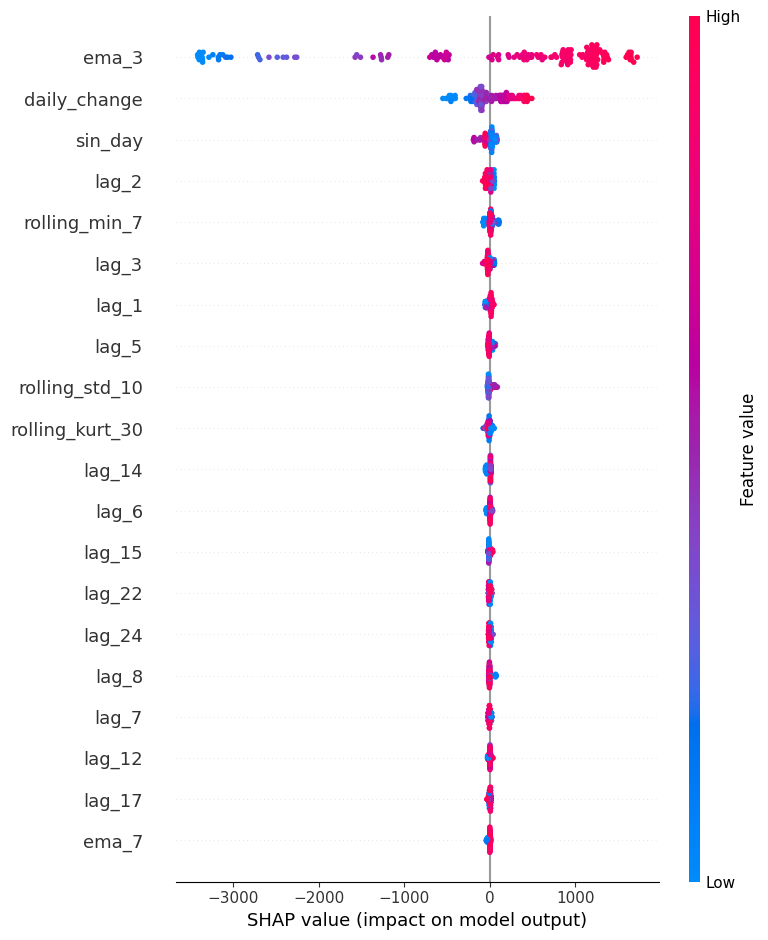

LightGBM R² Score: 0.9999999996011858
Predicted Quantities for Next 30 Days:
            Predicted_Quantity
2025-01-01              5096.0
2025-01-02              5014.0
2025-01-03              5072.0
2025-01-04              5127.0
2025-01-05              5059.0
2025-01-06              5117.0
2025-01-07              5090.0
2025-01-08              5138.0
2025-01-09              5140.0
2025-01-10              5136.0
2025-01-11              5126.0
2025-01-12              5163.0
2025-01-13              5135.0
2025-01-14              5127.0
2025-01-15              5068.0
2025-01-16              5078.0
2025-01-17              5055.0
2025-01-18              5061.0
2025-01-19              5075.0
2025-01-20              5064.0
2025-01-21              5052.0
2025-01-22              5050.0
2025-01-23              5055.0
2025-01-24              5041.0
2025-01-25              5062.0
2025-01-26              5074.0
2025-01-27              5029.0
2025-01-28              5031.0
2025-01-29              

In [ ]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
import numpy as np
from skopt import BayesSearchCV
import holidays
import shap

# Load dataset
df = pd.read_excel("/content/Forecasting_Data2.xlsx")

# Convert Posting Date to datetime and set as index
df['Posting Date'] = pd.to_datetime(df['Posting Date'])
df.set_index('Posting Date', inplace=True)

# Aggregate quantity by date
df = df.groupby(df.index).agg({'Qty in Un. of Entry': 'sum'})

# Sort data by date
df = df.sort_index()

### Feature Engineering ###
def create_features(data):
    df = data.copy()

    if 'Qty in Un. of Entry' not in df.columns:
        df['Qty in Un. of Entry'] = np.nan

    # Lag Features
    for lag in range(1, 31):  # Lags from 1 to 30 days
        df[f'lag_{lag}'] = df['Qty in Un. of Entry'].shift(lag)

    # Rolling Statistics
    df['rolling_mean_5'] = df['Qty in Un. of Entry'].rolling(window=5, min_periods=1).mean()
    df['rolling_std_10'] = df['Qty in Un. of Entry'].rolling(window=10, min_periods=1).std()
    df['rolling_median_30'] = df['Qty in Un. of Entry'].rolling(window=30, min_periods=1).median()

    # Additional Rolling Features (Enhancements)
    df['rolling_max_7'] = df['Qty in Un. of Entry'].rolling(window=7, min_periods=1).max()
    df['rolling_min_7'] = df['Qty in Un. of Entry'].rolling(window=7, min_periods=1).min()
    df['rolling_skew_30'] = df['Qty in Un. of Entry'].rolling(window=30, min_periods=1).skew()
    df['rolling_kurt_30'] = df['Qty in Un. of Entry'].rolling(window=30, min_periods=1).kurt()

    # Exponential Moving Averages (EMA)
    df['ema_3'] = df['Qty in Un. of Entry'].ewm(span=3, adjust=False).mean()
    df['ema_7'] = df['Qty in Un. of Entry'].ewm(span=7, adjust=False).mean()
    df['ema_14'] = df['Qty in Un. of Entry'].ewm(span=14, adjust=False).mean()

    # Historical Averages
    df['weekly_avg'] = df['Qty in Un. of Entry'].rolling(window=7, min_periods=1).mean()
    df['monthly_avg'] = df['Qty in Un. of Entry'].rolling(window=30, min_periods=1).mean()

    # Daily Change Feature
    df['daily_change'] = df['Qty in Un. of Entry'].diff()

    # Flag for Zero Quantities
    df['was_zero'] = (df['Qty in Un. of Entry'] == 0).astype(int)

    # Date-based Features
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Holiday Feature
    india_holidays = holidays.India(years=df.index.year.unique().tolist())
    df['is_holiday'] = df.index.map(lambda x: 1 if x in india_holidays else 0)

    # Fourier Transform Features for Seasonality
    df['sin_day'] = np.sin(2 * np.pi * df.index.dayofyear / 365)
    df['cos_day'] = np.cos(2 * np.pi * df.index.dayofyear / 365)

    # Fill NaN values
    df.bfill(inplace=True)  # Corrected deprecated method

    return df

# Apply feature engineering
df_features = create_features(df)

# Define Features & Target
X = df_features.drop(columns=['Qty in Un. of Entry'])
y = df_features['Qty in Un. of Entry']

# Time Series Split
tscv = TimeSeriesSplit(n_splits=10)

# Hyperparameter Tuning
param_space = {
    'n_estimators': (1000, 3000),
    'learning_rate': (0.01, 0.05, 'log-uniform'),
    'num_leaves': (20, 150),
    'min_child_samples': (10, 50),
    'subsample': (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0),
    'reg_alpha': (0.1, 1.5),
    'reg_lambda': (0.1, 1.5),
    'max_depth': (3, 10),
}

bayes_search = BayesSearchCV(
    lgb.LGBMRegressor(objective='regression', boosting_type='dart', verbose=-1),
    param_space,
    n_iter=100,
    cv=tscv,
    n_jobs=-1
)

bayes_search.fit(X, y)
best_params = bayes_search.best_params_

# Train Model
model = lgb.LGBMRegressor(**best_params, verbose=-1)
model.fit(X, y)

# Feature Importance using SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X)
shap.summary_plot(shap_values, X)

# Make Predictions
y_pred = model.predict(X)

# Evaluate Model
r2_lgbm = r2_score(y, y_pred)
print("LightGBM R² Score:", r2_lgbm)

# Forecasting Next 30 Days
start_date = df.index.max() + pd.Timedelta(days=1)
future_dates = pd.date_range(start=start_date, periods=30, freq='D')
future_df = pd.DataFrame(index=future_dates)

future_features = create_features(pd.concat([df, future_df])).reindex(future_dates)
future_X = future_features.drop(columns=['Qty in Un. of Entry'], errors='ignore')
future_predictions = model.predict(future_X)
future_predictions = np.maximum(0, np.round(future_predictions))

forecast_df = pd.DataFrame({'Predicted_Quantity': future_predictions}, index=future_dates)
print("Predicted Quantities for Next 30 Days:")
print(forecast_df)


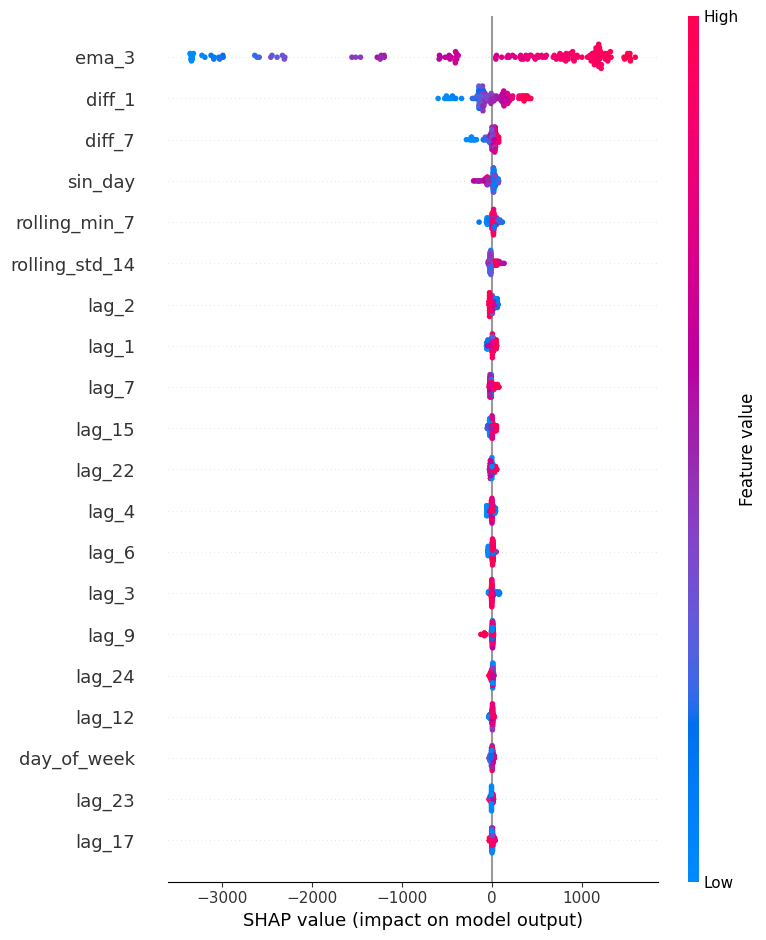

LightGBM Model Performance:
MAE: 0.05
RMSE: 0.13
R² Score: 1.0000

Predicted Quantities for Next 30 Days:
            Predicted_Quantity
2025-01-01              5296.0
2025-01-02              5003.0
2025-01-03              5113.0
2025-01-04              5193.0
2025-01-05              5056.0
2025-01-06              5132.0
2025-01-07              5156.0
2025-01-08              5170.0
2025-01-09              5155.0
2025-01-10              5105.0
2025-01-11              5138.0
2025-01-12              5218.0
2025-01-13              5075.0
2025-01-14              5088.0
2025-01-15              5083.0
2025-01-16              5051.0
2025-01-17              5024.0
2025-01-18              5033.0
2025-01-19              5024.0
2025-01-20              4985.0
2025-01-21              4993.0
2025-01-22              5032.0
2025-01-23              5040.0
2025-01-24              4985.0
2025-01-25              5001.0
2025-01-26              5013.0
2025-01-27              5023.0
2025-01-28              50

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skopt import BayesSearchCV
import holidays
import shap

# Load dataset
df = pd.read_excel("/content/Forecasting_Data2.xlsx")

# Convert Posting Date to datetime and set as index
df['Posting Date'] = pd.to_datetime(df['Posting Date'])
df.set_index('Posting Date', inplace=True)

# Aggregate quantity by date
df = df.groupby(df.index).agg({'Qty in Un. of Entry': 'sum'})

# Sort data by date
df = df.sort_index()

### Feature Engineering ###
def create_features(data):
    df = data.copy()

    # Lag Features
    for lag in range(1, 30):
        df[f'lag_{lag}'] = df['Qty in Un. of Entry'].shift(lag)

    # Rolling Statistics
    df['rolling_mean_7'] = df['Qty in Un. of Entry'].rolling(window=7, min_periods=1).mean()
    df['rolling_std_14'] = df['Qty in Un. of Entry'].rolling(window=14, min_periods=1).std()
    df['rolling_max_7'] = df['Qty in Un. of Entry'].rolling(window=7, min_periods=1).max()
    df['rolling_min_7'] = df['Qty in Un. of Entry'].rolling(window=7, min_periods=1).min()

    # Exponential Moving Averages (EMA)
    df['ema_3'] = df['Qty in Un. of Entry'].ewm(span=3, adjust=False).mean()
    df['ema_7'] = df['Qty in Un. of Entry'].ewm(span=7, adjust=False).mean()

    # Differencing to Remove Trend
    df['diff_1'] = df['Qty in Un. of Entry'].diff(1)
    df['diff_7'] = df['Qty in Un. of Entry'].diff(7)

    # Fourier Transform Features for Seasonality
    df['sin_day'] = np.sin(2 * np.pi * df.index.dayofyear / 365)
    df['cos_day'] = np.cos(2 * np.pi * df.index.dayofyear / 365)

    # Date-based Features
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Holiday Feature
    india_holidays = holidays.India(years=df.index.year.unique().tolist())
    df['is_holiday'] = df.index.map(lambda x: 1 if x in india_holidays else 0)

    # Fill NaN values
    df.bfill(inplace=True)


    return df

# Apply feature engineering
df_features = create_features(df)

# Define Features & Target
X = df_features.drop(columns=['Qty in Un. of Entry'])
y = df_features['Qty in Un. of Entry']

# Time Series Split
tscv = TimeSeriesSplit(n_splits=10)

# Hyperparameter Tuning
param_space = {
    'n_estimators': (500, 3000),
    'learning_rate': (0.005, 0.05, 'log-uniform'),
    'num_leaves': (20, 150),
    'min_child_samples': (10, 50),
    'subsample': (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0),
    'reg_alpha': (0.1, 1.5),
    'reg_lambda': (0.1, 1.5),
    'max_depth': (3, 10),
}

bayes_search = BayesSearchCV(
    lgb.LGBMRegressor(objective='regression', boosting_type='dart', verbose=-1),
    param_space,
    n_iter=50,
    cv=tscv,
    n_jobs=-1
)

bayes_search.fit(X, y)
best_params = bayes_search.best_params_

# Train Model
model = lgb.LGBMRegressor(**best_params, verbose=-1)
model.fit(X, y)

# Feature Importance using SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X)
shap.summary_plot(shap_values, X)

# Make Predictions
y_pred = model.predict(X)

# Evaluate Model
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print(f"LightGBM Model Performance:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Forecasting Next 30 Days
start_date = df.index.max() + pd.Timedelta(days=1)
future_dates = pd.date_range(start=start_date, periods=30, freq='D')
future_df = pd.DataFrame(index=future_dates)

future_features = create_features(pd.concat([df, future_df])).reindex(future_dates)
future_X = future_features.drop(columns=['Qty in Un. of Entry'], errors='ignore')
future_predictions = model.predict(future_X)
future_predictions = np.maximum(0, np.round(future_predictions))

forecast_df = pd.DataFrame({'Predicted_Quantity': future_predictions}, index=future_dates)
print("\nPredicted Quantities for Next 30 Days:")
print(forecast_df)


In [ ]:
!pip install bayesian-optimization


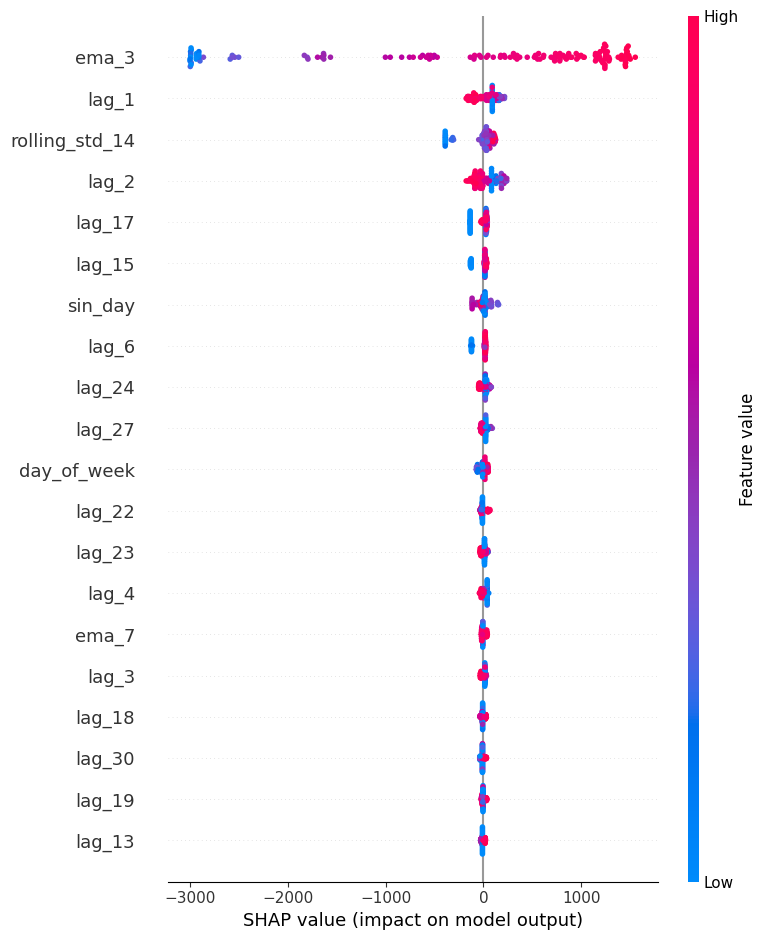

LightGBM Model Performance:
MAE: 79.07
RMSE: 115.28
R² Score: 0.9950

Predicted Quantities for Next 30 Days:
            Predicted_Quantity
2025-01-01              5287.0
2025-01-02              5476.0
2025-01-03              5497.0
2025-01-04              5612.0
2025-01-05              5644.0
2025-01-06              5653.0
2025-01-07              4965.0
2025-01-08              4996.0
2025-01-09              4973.0
2025-01-10              4956.0
2025-01-11              5024.0
2025-01-12              4953.0
2025-01-13              4862.0
2025-01-14              4866.0
2025-01-15              4961.0
2025-01-16              4726.0
2025-01-17              4734.0
2025-01-18              4459.0
2025-01-19              4524.0
2025-01-20              4432.0
2025-01-21              4436.0
2025-01-22              4431.0
2025-01-23              4422.0
2025-01-24              4475.0
2025-01-25              4568.0
2025-01-26              4542.0
2025-01-27              4521.0
2025-01-28             

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import holidays
import shap

# Load dataset
df = pd.read_excel("/content/Forecasting_Data2.xlsx")

# Convert Posting Date to datetime and set as index
df['Posting Date'] = pd.to_datetime(df['Posting Date'])
df.set_index('Posting Date', inplace=True)

# Aggregate quantity by date
df = df.groupby(df.index).agg({'Qty in Un. of Entry': 'sum'})

# Sort data by date
df = df.sort_index()

### Feature Engineering ###
def create_features(data):
    df = data.copy()

    # Lag Features (Increased to 30 days)
    for lag in range(1, 31):
        df[f'lag_{lag}'] = df['Qty in Un. of Entry'].shift(lag)

    # Rolling Statistics (Keeping only essential)
    df['rolling_mean_7'] = df['Qty in Un. of Entry'].rolling(window=7, min_periods=1).mean()
    df['rolling_std_14'] = df['Qty in Un. of Entry'].rolling(window=14, min_periods=1).std()

    # Exponential Moving Averages (EMA)
    df['ema_3'] = df['Qty in Un. of Entry'].ewm(span=3, adjust=False).mean()
    df['ema_7'] = df['Qty in Un. of Entry'].ewm(span=7, adjust=False).mean()

    # Fourier Transform Features for Seasonality
    df['sin_day'] = np.sin(2 * np.pi * df.index.dayofyear / 365)
    df['cos_day'] = np.cos(2 * np.pi * df.index.dayofyear / 365)

    # Date-based Features
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Holiday Feature
    india_holidays = holidays.India(years=df.index.year.unique().tolist())
    df['is_holiday'] = df.index.map(lambda x: 1 if x in india_holidays else 0)

    # Fill NaN values
    df.bfill(inplace=True)

    return df

# Apply feature engineering
df_features = create_features(df)

# Define Features & Target
X = df_features.drop(columns=['Qty in Un. of Entry'])
y = df_features['Qty in Un. of Entry']

# Time Series Split
tscv = TimeSeriesSplit(n_splits=10)

# Train Model with LightGBM (Default Hyperparameters)
model = lgb.LGBMRegressor(objective='regression', boosting_type='dart', verbose=-1, n_estimators=1000)
model.fit(X, y)

# Feature Importance using SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X)
shap.summary_plot(shap_values, X)

# Make Predictions
y_pred = model.predict(X)

# Evaluate Model
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print(f"LightGBM Model Performance:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Forecasting Next 30 Days
start_date = df.index.max() + pd.Timedelta(days=1)
future_dates = pd.date_range(start=start_date, periods=30, freq='D')
future_df = pd.DataFrame(index=future_dates)

future_features = create_features(pd.concat([df, future_df])).reindex(future_dates)
future_X = future_features.drop(columns=['Qty in Un. of Entry'], errors='ignore')
future_predictions = model.predict(future_X)
future_predictions = np.maximum(0, np.round(future_predictions))

forecast_df = pd.DataFrame({'Predicted_Quantity': future_predictions}, index=future_dates)
print("\nPredicted Quantities for Next 30 Days:")
print(forecast_df)


Column Names in DataFrame: Index(['Material Document', 'Material', 'Material Description',
       'Qty in Un. of Entry', 'Unit of Entry', 'Plant', 'Storage Location',
       'Movement Type', 'Posting Date', 'Purchase Order', 'Vendor',
       'Reference', 'Document Date', 'Time of Entry', 'Order Price Unit',
       'Special Stock', 'Asset', 'WBS Element', 'Amount in LC', 'Name 1',
       'Base Unit of Measure', 'Batch', 'Company Code', 'Consumption',
       'Cost Center', 'Counter', 'Currency', 'Customer', 'Debit/Credit Ind.',
       'Entry Date', 'Item', 'Item No.Stock Transfer Reserv.',
       'Material Doc. Year', 'Reservation', 'User name', 'Receipt Indicator',
       'Reason for Movement', 'Document Header Text'],
      dtype='object')


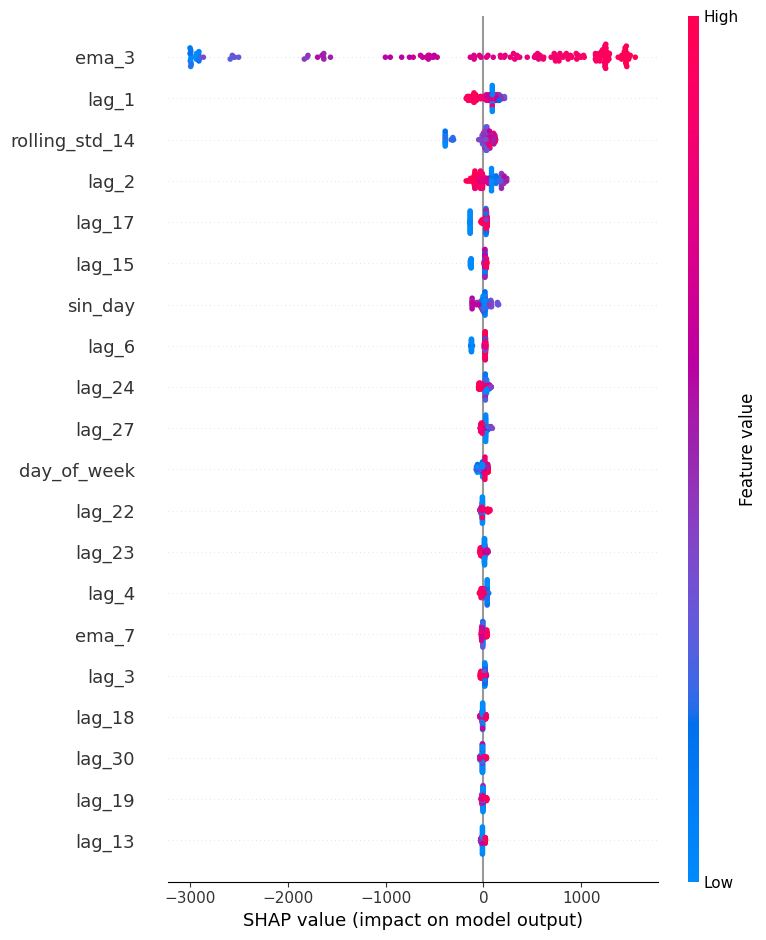

LightGBM Model Performance:
R² Score: 0.9950

Predicted Quantities for Next 30 Days:
            Predicted_Quantity
2025-01-01              5287.0
2025-01-02              5476.0
2025-01-03              5497.0
2025-01-04              5612.0
2025-01-05              5644.0
2025-01-06              5653.0
2025-01-07              4965.0
2025-01-08              4996.0
2025-01-09              4973.0
2025-01-10              4956.0
2025-01-11              5024.0
2025-01-12              4953.0
2025-01-13              4862.0
2025-01-14              4866.0
2025-01-15              4961.0
2025-01-16              4726.0
2025-01-17              4734.0
2025-01-18              4459.0
2025-01-19              4524.0
2025-01-20              4432.0
2025-01-21              4436.0
2025-01-22              4431.0
2025-01-23              4422.0
2025-01-24              4475.0
2025-01-25              4568.0
2025-01-26              4542.0
2025-01-27              4521.0
2025-01-28              4589.0
2025-01-29      

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
import holidays
import shap

# Load dataset (Ensure the correct engine is used)
df = pd.read_excel("/content/Forecasting_Data2.xlsx", engine="openpyxl")

# Display column names to check for unexpected issues
print("Column Names in DataFrame:", df.columns)

# Ensure column name consistency
df.columns = df.columns.str.strip()  # Removes leading/trailing spaces

# Convert Posting Date to datetime and set as index
df['Posting Date'] = pd.to_datetime(df['Posting Date'])
df.set_index('Posting Date', inplace=True)

# Ensure 'Qty in Un. of Entry' exists before aggregation
if 'Qty in Un. of Entry' not in df.columns:
    raise KeyError("The expected column 'Qty in Un. of Entry' is missing. Please check the dataset.")

# Aggregate quantity by date
df = df.groupby(df.index).agg({'Qty in Un. of Entry': 'sum'})

# Sort data by date
df = df.sort_index()

### Feature Engineering ###
def create_features(data):
    df = data.copy()

    # Lag Features (Increased to 30 days)
    for lag in range(1, 31):
        df[f'lag_{lag}'] = df['Qty in Un. of Entry'].shift(lag)

    # Rolling Statistics (Keeping only essential)
    df['rolling_mean_7'] = df['Qty in Un. of Entry'].rolling(window=7, min_periods=1).mean()
    df['rolling_std_14'] = df['Qty in Un. of Entry'].rolling(window=14, min_periods=1).std()

    # Exponential Moving Averages (EMA)
    df['ema_3'] = df['Qty in Un. of Entry'].ewm(span=3, adjust=False).mean()
    df['ema_7'] = df['Qty in Un. of Entry'].ewm(span=7, adjust=False).mean()

    # Fourier Transform Features for Seasonality
    df['sin_day'] = np.sin(2 * np.pi * df.index.dayofyear / 365)
    df['cos_day'] = np.cos(2 * np.pi * df.index.dayofyear / 365)

    # Date-based Features
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Holiday Feature
    india_holidays = holidays.India(years=df.index.year.unique().tolist())
    df['is_holiday'] = df.index.map(lambda x: 1 if x in india_holidays else 0)

    # Fill NaN values (important for forecasting)
    df.bfill(inplace=True)


    return df

# Apply feature engineering
df_features = create_features(df)

# Define Features & Target
X = df_features.drop(columns=['Qty in Un. of Entry'])
y = df_features['Qty in Un. of Entry']

# Train Model with LightGBM (Default Hyperparameters)
model = lgb.LGBMRegressor(objective='regression', boosting_type='dart', verbose=-1, n_estimators=1000)
model.fit(X, y)

# Feature Importance using SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X)
shap.summary_plot(shap_values, X)

# Make Predictions
y_pred = model.predict(X)

# Evaluate Model (Only R² Score)
r2 = r2_score(y, y_pred)

print(f"LightGBM Model Performance:")
print(f"R² Score: {r2:.4f}")

### Forecasting Next 30 Days ###
future_dates = pd.date_range(start=df.index.max() + pd.Timedelta(days=1), periods=30, freq='D')
future_df = pd.DataFrame(index=future_dates)

# Generate features for forecasting
df_extended = pd.concat([df, future_df])
future_features = create_features(df_extended).reindex(future_dates)
future_X = future_features.drop(columns=['Qty in Un. of Entry'], errors='ignore')

# Predict the next 30 days
future_predictions = model.predict(future_X)
future_predictions = np.maximum(0, np.round(future_predictions))

forecast_df = pd.DataFrame({'Predicted_Quantity': future_predictions}, index=future_dates)

print("\nPredicted Quantities for Next 30 Days:")
print(forecast_df)


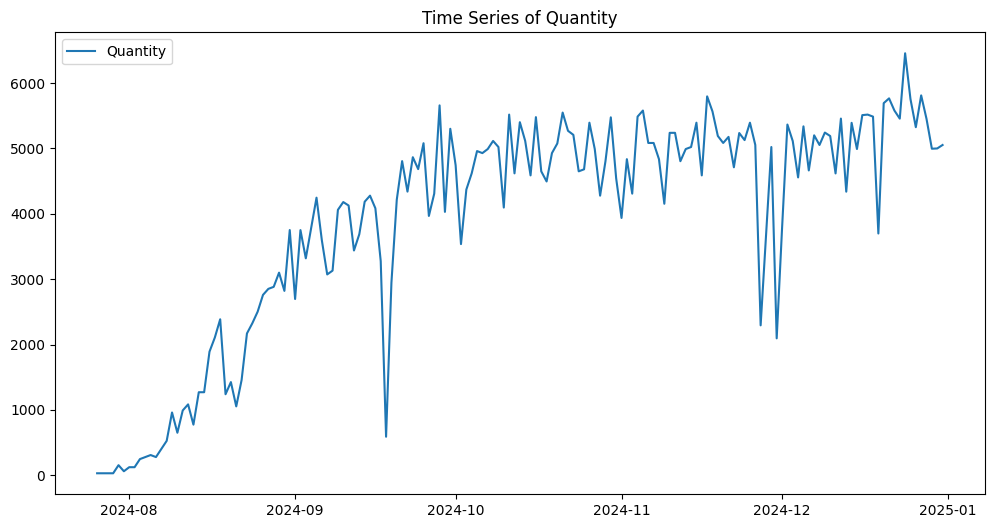

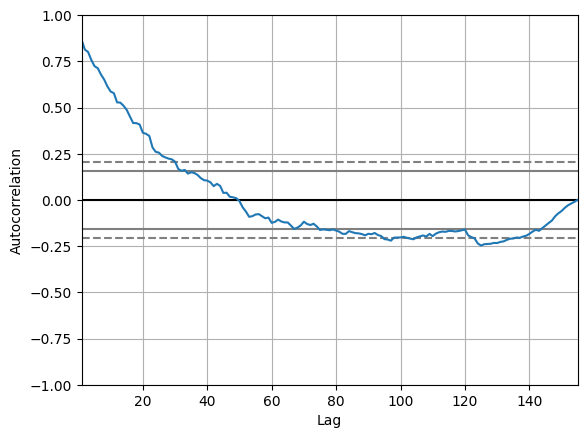

Best Hyperparameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 1000, 'num_leaves': 31, 'subsample': 0.7}


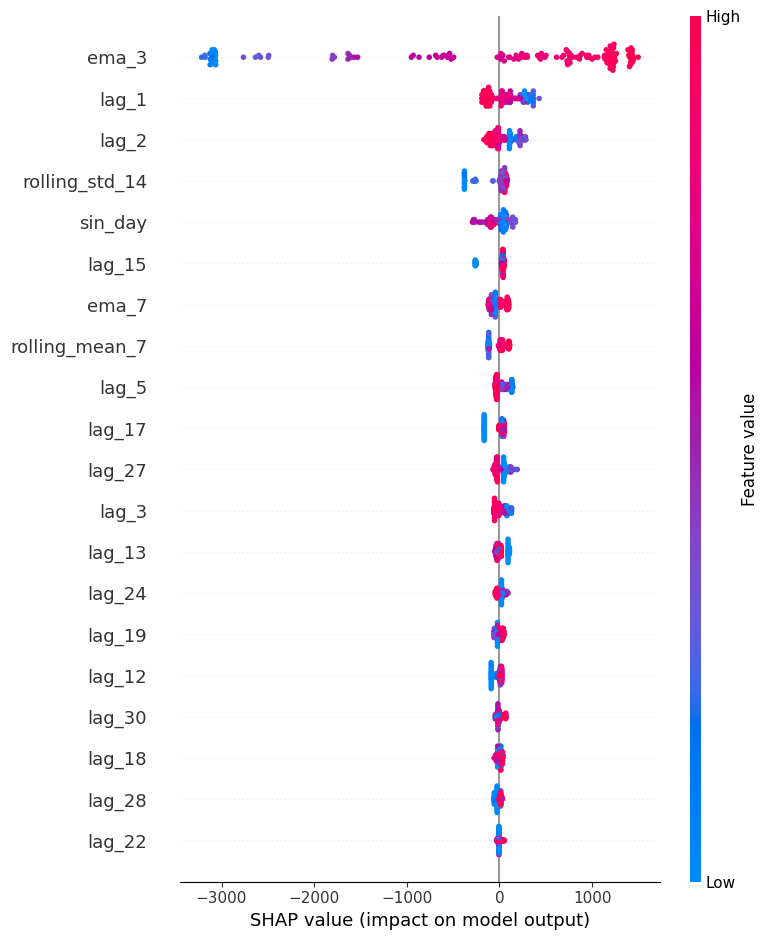

Model Performance:
R² Score: 0.9993
MAE: 17.5374
RMSE: 42.0383

Predicted Quantities for Next 30 Days:
            Predicted_Quantity
2025-01-01              5296.0
2025-01-02              5767.0
2025-01-03              5874.0
2025-01-04              5963.0
2025-01-05              5940.0
2025-01-06              6056.0
2025-01-07              5293.0
2025-01-08              5419.0
2025-01-09              5385.0
2025-01-10              5330.0
2025-01-11              5350.0
2025-01-12              5259.0
2025-01-13              5208.0
2025-01-14              5216.0
2025-01-15              5238.0
2025-01-16              4856.0
2025-01-17              4823.0
2025-01-18              4497.0
2025-01-19              4545.0
2025-01-20              4492.0
2025-01-21              4482.0
2025-01-22              4480.0
2025-01-23              4493.0
2025-01-24              4493.0
2025-01-25              4522.0
2025-01-26              4507.0
2025-01-27              4500.0
2025-01-28              4527.

In [35]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import holidays
import shap
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_excel("/content/Forecasting_Data2.xlsx", engine="openpyxl")

# Clean column names
df.columns = df.columns.str.strip()

# Convert Posting Date to datetime and set as index
df['Posting Date'] = pd.to_datetime(df['Posting Date'])
df.set_index('Posting Date', inplace=True)

# Aggregate quantity by date
df = df.groupby(df.index).agg({'Qty in Un. of Entry': 'sum'})
df.sort_index(inplace=True)

# Check data distribution
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Qty in Un. of Entry'], label='Quantity')
plt.title("Time Series of Quantity")
plt.legend()
plt.show()

# Autocorrelation Plot
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(df['Qty in Un. of Entry'])
plt.show()

# Feature Engineering
def create_features(data):
    df = data.copy()

    # Lag Features (Optimal Lags Based on ACF Analysis)
    for lag in range(1, 31):
        df[f'lag_{lag}'] = df['Qty in Un. of Entry'].shift(lag)

    # Rolling Statistics
    df['rolling_mean_7'] = df['Qty in Un. of Entry'].rolling(window=7, min_periods=1).mean()
    df['rolling_std_14'] = df['Qty in Un. of Entry'].rolling(window=14, min_periods=1).std()

    # Exponential Moving Averages
    df['ema_3'] = df['Qty in Un. of Entry'].ewm(span=3, adjust=False).mean()
    df['ema_7'] = df['Qty in Un. of Entry'].ewm(span=7, adjust=False).mean()

    # Fourier Features for Seasonality
    df['sin_day'] = np.sin(2 * np.pi * df.index.dayofyear / 365)
    df['cos_day'] = np.cos(2 * np.pi * df.index.dayofyear / 365)

    # Date Features
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Holiday Feature
    india_holidays = holidays.India(years=df.index.year.unique().tolist())
    df['is_holiday'] = df.index.map(lambda x: 1 if x in india_holidays else 0)

    # Fill NaN values
    df.bfill(inplace=True)
    return df

# Apply feature engineering
df_features = create_features(df)

# Define Features & Target
X = df_features.drop(columns=['Qty in Un. of Entry'])
y = df_features['Qty in Un. of Entry']

# Model Tuning with Grid Search
param_grid = {
    'learning_rate': [0.005, 0.01, 0.05],
    'num_leaves': [31, 50, 70],
    'max_depth': [5, 10, 15],
    'n_estimators': [1000, 2000, 3000],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

model = lgb.LGBMRegressor(boosting_type='dart', objective='huber', alpha=0.9, random_state=42)
grid_search = GridSearchCV(model, param_grid, cv=3, scoring='r2')
grid_search.fit(X, y)
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Train Model with Best Parameters
model = lgb.LGBMRegressor(**best_params)
model.fit(X, y)

# Feature Importance using SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X)
shap.summary_plot(shap_values, X)

# Predictions
y_pred = model.predict(X)

# Model Evaluation
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print(f"Model Performance:")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Forecasting Next 30 Days
future_dates = pd.date_range(start=df.index.max() + pd.Timedelta(days=1), periods=30, freq='D')
future_df = pd.DataFrame(index=future_dates)

df_extended = pd.concat([df, future_df])
future_features = create_features(df_extended).reindex(future_dates)
future_X = future_features.drop(columns=['Qty in Un. of Entry'], errors='ignore')

future_predictions = model.predict(future_X)
future_predictions = np.maximum(0, np.round(future_predictions))

forecast_df = pd.DataFrame({'Predicted_Quantity': future_predictions}, index=future_dates)
print("\nPredicted Quantities for Next 30 Days:")
print(forecast_df)
